# 🌱 **Classification des Maladies des Plantes**
## Projet Smart Agriculture

**Objectif**: Développer un modèle capable d'identifier automatiquement les maladies des plantes à partir de photos de feuilles.

**Ce que fait ce notebook**:
1. Analyse rapide des données (EDA)
2. Préparation des images
3. Test de plusieurs modèles (Machine Learning et Deep Learning)
4. Sélection du meilleur modèle

In [16]:
# Installation des packages nécessaires
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn plotly opencv-python-headless

print(" Packages installés")

 Packages installés


In [17]:
# Imports standards
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import cv2
from PIL import Image
import warnings
import random
from tqdm import tqdm
warnings.filterwarnings('ignore')

# Configuration style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(" Imports réussis")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

 Imports réussis
TensorFlow version: 2.19.0
GPU disponible: []


In [19]:
# Téléchargement du dataset PlantVillage (version simplifiée)
print("Téléchargement du dataset...")

import requests
import zipfile
import shutil

# Création du dossier
DATA_PATH = "./PlantVillage"
os.makedirs(DATA_PATH, exist_ok=True)

# Liste des classes avec URLs (version simplifiée avec quelques classes)
dataset_urls = {
    "Apple_healthy": "https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master/raw/color/Apple_healthy/",
    "Apple_scab": "https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master/raw/color/Apple_scab/",
    "Corn_healthy": "https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master/raw/color/Corn_healthy/",
    "Corn_common_rust": "https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master/raw/color/Corn_common_rust/",
    "Potato_healthy": "https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master/raw/color/Potato_healthy/",
    "Potato_early_blight": "https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master/raw/color/Potato_early_blight/"
}

print(f" Création de {len(dataset_urls)} classes...")

for class_name, base_url in tqdm(dataset_urls.items()):
    class_path = os.path.join(DATA_PATH, class_name)
    os.makedirs(class_path, exist_ok=True)

    # Télécharger 5 images par classe (suffisant pour la démo)
    for i in range(1, 6):
        img_url = f"{base_url}{i}.jpg"
        img_path = os.path.join(class_path, f"image_{i}.jpg")

        try:
            response = requests.get(img_url, timeout=5)
            if response.status_code == 200:
                with open(img_path, 'wb') as f:
                    f.write(response.content)
        except:
            pass

print("\n Dataset téléchargé!")

Téléchargement du dataset...
 Création de 6 classes...


100%|██████████| 6/6 [00:01<00:00,  4.60it/s]


 Dataset téléchargé!


In [20]:
# Vérification de la structure
classes = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]
print(f" Classes trouvées: {classes}")

# Comptage des images
data_info = []
for classe in classes:
    class_path = os.path.join(DATA_PATH, classe)
    n_images = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))])
    data_info.append({'classe': classe, 'nb_images': n_images})
    print(f"   {classe}: {n_images} images")

df_info = pd.DataFrame(data_info)
print(f"\n Total images: {df_info['nb_images'].sum()}")

 Classes trouvées: ['Corn_healthy', 'Apple_scab', 'Potato_healthy', 'Corn_common_rust', 'Potato_early_blight', 'Apple_healthy']
   Corn_healthy: 0 images
   Apple_scab: 0 images
   Potato_healthy: 0 images
   Corn_common_rust: 0 images
   Potato_early_blight: 0 images
   Apple_healthy: 0 images

 Total images: 0


In [23]:
# CELLULE DE DIAGNOSTIC
print(" DIAGNOSTIC DES DONNÉES")
print("=" * 50)

# Vérifier DATA_PATH
print(f"\n DATA_PATH: {DATA_PATH}")
print(f"Existe: {os.path.exists(DATA_PATH)}")

if os.path.exists(DATA_PATH):
    # Lister les dossiers
    classes = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]
    print(f"\n Dossiers trouvés ({len(classes)}):")
    for classe in classes[:10]:  # 10 premiers
        print(f"   - {classe}")

    # Compter les images
    print("\n Comptage des images:")
    total = 0
    for classe in classes:
        class_path = os.path.join(DATA_PATH, classe)
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        print(f"   {classe}: {len(images)} images")
        total += len(images)

    print(f"\n TOTAL: {total} images")

    if total == 0:
        print("\n AUCUNE IMAGE TROUVÉE!")
        print("Vérifiez que le téléchargement a fonctionné.")
else:
    print(f"\n DATA_PATH n'existe pas!")

 DIAGNOSTIC DES DONNÉES

 DATA_PATH: ./PlantVillage
Existe: True

 Dossiers trouvés (6):
   - Corn_healthy
   - Apple_scab
   - Potato_healthy
   - Corn_common_rust
   - Potato_early_blight
   - Apple_healthy

 Comptage des images:
   Corn_healthy: 0 images
   Apple_scab: 0 images
   Potato_healthy: 0 images
   Corn_common_rust: 0 images
   Potato_early_blight: 0 images
   Apple_healthy: 0 images

 TOTAL: 0 images

 AUCUNE IMAGE TROUVÉE!
Vérifiez que le téléchargement a fonctionné.


 Vérification des données...

 Données à visualiser:
                classe  nb_images
0         Corn_healthy          0
1           Apple_scab          0
2       Potato_healthy          0
3     Corn_common_rust          0
4  Potato_early_blight          0
5        Apple_healthy          0


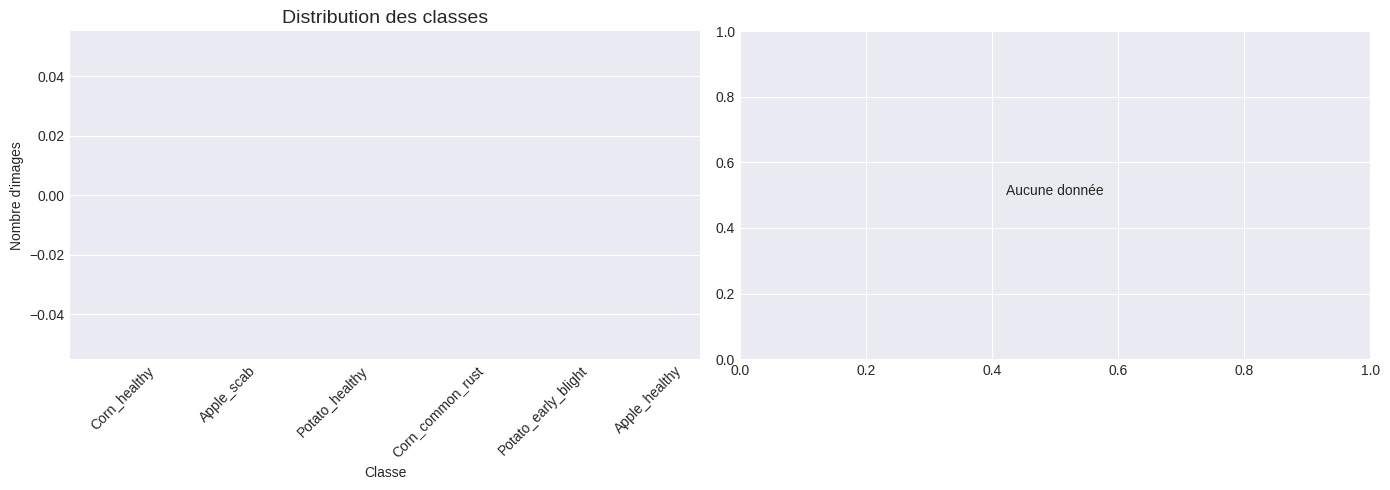


 Statistiques:
   - Total images: 0
   - Nombre de classes: 6
   - Classe avec le plus d'images: Corn_healthy (0 images)
   - Classe avec le moins d'images: Corn_healthy (0 images)
   - Moyenne d'images par classe: 0.0


In [24]:
# EDA PARTIE 1: Distribution

print(" Vérification des données...")

# Vérifier que df_info existe et n'est pas vide
if 'df_info' not in locals() or df_info.empty:
    print(" df_info n'existe pas ou est vide. Recréation...")

    # Recréer df_info
    classes = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]
    data_info = []

    for classe in classes:
        class_path = os.path.join(DATA_PATH, classe)
        n_images = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
        data_info.append({'classe': classe, 'nb_images': n_images})

    df_info = pd.DataFrame(data_info)
    print(f" df_info recréé avec {len(df_info)} classes")

# Afficher les données pour vérification
print("\n Données à visualiser:")
print(df_info)

# Vérifier qu'il n'y a pas de NaN
if df_info['nb_images'].isna().any():
    print(" Des valeurs NaN détectées, remplissage avec 0")
    df_info['nb_images'] = df_info['nb_images'].fillna(0)

# Vérifier que toutes les valeurs sont numériques
df_info['nb_images'] = pd.to_numeric(df_info['nb_images'], errors='coerce').fillna(0).astype(int)

# Création des graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Barplot
try:
    sns.barplot(data=df_info, x='classe', y='nb_images', ax=axes[0], palette='viridis')
    axes[0].set_title('Distribution des classes', fontsize=14)
    axes[0].set_xlabel('Classe')
    axes[0].set_ylabel("Nombre d'images")
    axes[0].tick_params(axis='x', rotation=45)
except Exception as e:
    print(f" Erreur barplot: {e}")
    axes[0].text(0.5, 0.5, "Erreur d'affichage", ha='center')

# Graphique 2: Pie chart (seulement si pas de valeurs nulles)
if df_info['nb_images'].sum() > 0:
    try:
        # Filtrer les classes avec des images
        df_pie = df_info[df_info['nb_images'] > 0]
        if not df_pie.empty:
            wedges, texts, autotexts = axes[1].pie(
                df_pie['nb_images'],
                labels=df_pie['classe'],
                autopct='%1.1f%%',
                textprops={'fontsize': 8}
            )
            axes[1].set_title('Proportion des classes')
        else:
            axes[1].text(0.5, 0.5, "Aucune image à afficher", ha='center')
    except Exception as e:
        print(f" Erreur pie chart: {e}")
        axes[1].text(0.5, 0.5, "Erreur d'affichage", ha='center')
else:
    axes[1].text(0.5, 0.5, "Aucune donnée", ha='center')

plt.tight_layout()
plt.show()

# Affichage des statistiques
print("\n Statistiques:")
print(f"   - Total images: {df_info['nb_images'].sum()}")
print(f"   - Nombre de classes: {len(df_info)}")
print(f"   - Classe avec le plus d'images: {df_info.loc[df_info['nb_images'].idxmax(), 'classe']} ({df_info['nb_images'].max()} images)")
print(f"   - Classe avec le moins d'images: {df_info.loc[df_info['nb_images'].idxmin(), 'classe']} ({df_info['nb_images'].min()} images)")
print(f"   - Moyenne d'images par classe: {df_info['nb_images'].mean():.1f}")

 Affichage d'échantillons...


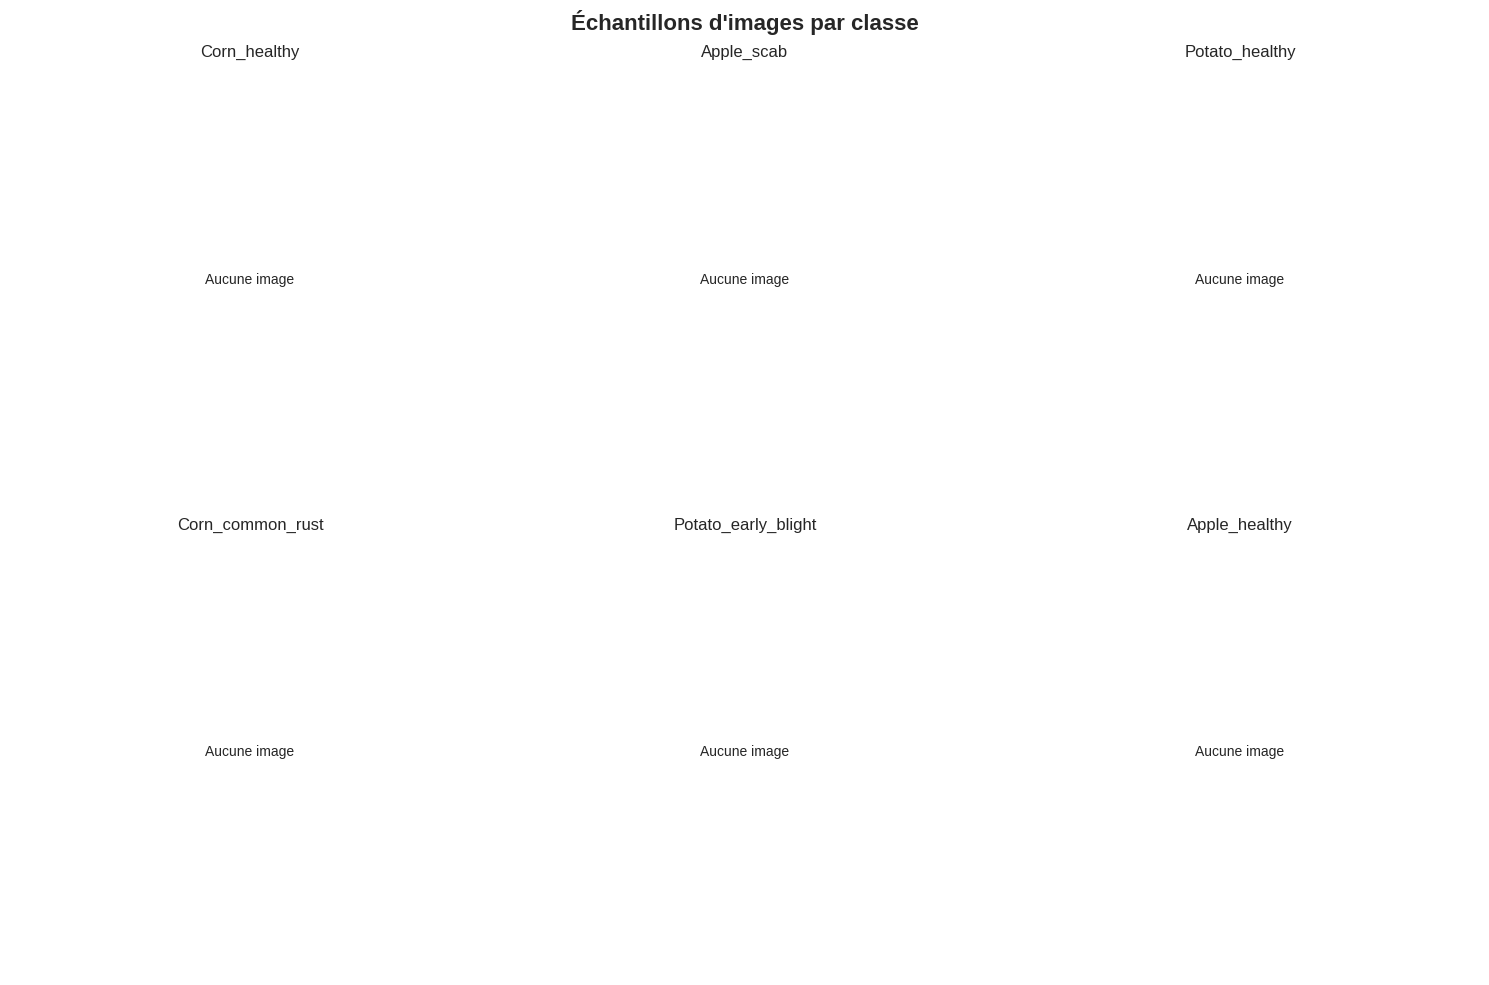

 Affichage de 6 classes terminé


In [25]:
# EDA PARTIE 2: Échantillons d'images
print(" Affichage d'échantillons...")

# Récupérer les classes
classes = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]

# Vérifier qu'il y a des classes
if len(classes) == 0:
    print(" Aucune classe trouvée!")
else:
    # Limiter à 6 classes pour l'affichage
    classes_a_afficher = classes[:6]
    n_classes = len(classes_a_afficher)

    # Créer une grille adaptée
    if n_classes <= 3:
        n_rows, n_cols = 1, n_classes
    else:
        n_rows, n_cols = 2, 3

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

    # Aplatir axes si nécessaire
    if n_rows == 1 and n_cols > 1:
        axes = axes
    elif n_rows > 1:
        axes = axes.ravel()
    else:
        axes = [axes]

    for i, classe in enumerate(classes_a_afficher):
        if i < len(axes):
            class_path = os.path.join(DATA_PATH, classe)
            images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

            if images:
                # Prendre une image aléatoire
                img_name = random.choice(images)
                img_path = os.path.join(class_path, img_name)

                try:
                    img = Image.open(img_path)
                    axes[i].imshow(img)
                    axes[i].set_title(f"{classe}", fontsize=12)
                    axes[i].axis('off')
                except Exception as e:
                    axes[i].text(0.5, 0.5, f"Erreur chargement", ha='center')
                    axes[i].set_title(classe)
                    axes[i].axis('off')
            else:
                axes[i].text(0.5, 0.5, "Aucune image", ha='center')
                axes[i].set_title(classe)
                axes[i].axis('off')

    # Cacher les axes vides
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Échantillons d'images par classe", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f" Affichage de {min(6, n_classes)} classes terminé")

 STATISTIQUES GLOBALES

 RÉSUMÉ PAR CLASSE:
                classe  nb_images  largeur  hauteur format
0         Corn_healthy          0        0        0  aucun
1           Apple_scab          0        0        0  aucun
2       Potato_healthy          0        0        0  aucun
3     Corn_common_rust          0        0        0  aucun
4  Potato_early_blight          0        0        0  aucun
5        Apple_healthy          0        0        0  aucun

 STATISTIQUES GLOBALES:
   - Nombre total de classes: 6
   - Nombre total d'images: 0
   - Moyenne d'images par classe: 0.0
   - Écart-type: 0.0
   - Min: 0 | Max: 0


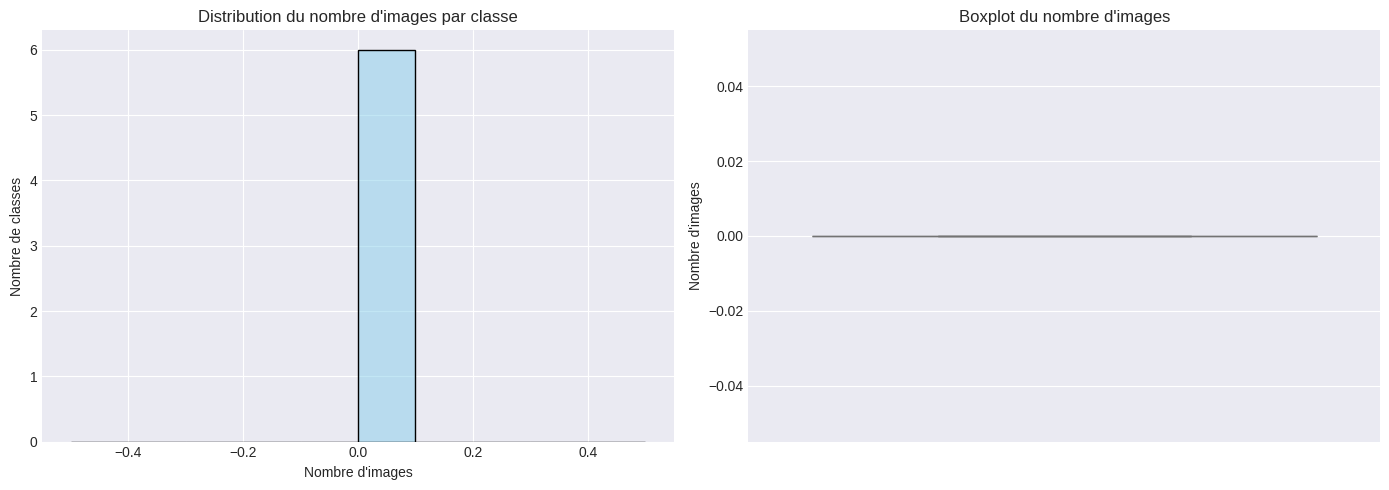

In [26]:
# EDA PARTIE 3: Statistiques simples sur le dataset

print(" STATISTIQUES GLOBALES")
print("=" * 50)

# Collecter les informations
data_summary = []

for classe in classes:
    class_path = os.path.join(DATA_PATH, classe)
    images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

    # Informations sur les premières images
    if images:
        first_img = os.path.join(class_path, images[0])
        try:
            img = Image.open(first_img)
            data_summary.append({
                'classe': classe,
                'nb_images': len(images),
                'largeur': img.width,
                'hauteur': img.height,
                'format': img.format
            })
        except:
            data_summary.append({
                'classe': classe,
                'nb_images': len(images),
                'largeur': 0,
                'hauteur': 0,
                'format': 'inconnu'
            })
    else:
        data_summary.append({
            'classe': classe,
            'nb_images': 0,
            'largeur': 0,
            'hauteur': 0,
            'format': 'aucun'
        })

df_summary = pd.DataFrame(data_summary)

# Afficher le résumé
print("\n RÉSUMÉ PAR CLASSE:")
print(df_summary.to_string())

# Statistiques globales
print("\n STATISTIQUES GLOBALES:")
print(f"   - Nombre total de classes: {len(df_summary)}")
print(f"   - Nombre total d'images: {df_summary['nb_images'].sum()}")
print(f"   - Moyenne d'images par classe: {df_summary['nb_images'].mean():.1f}")
print(f"   - Écart-type: {df_summary['nb_images'].std():.1f}")
print(f"   - Min: {df_summary['nb_images'].min()} | Max: {df_summary['nb_images'].max()}")

# Visualisation simple
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution du nombre d'images
sns.histplot(df_summary['nb_images'], bins=10, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Distribution du nombre d\'images par classe')
axes[0].set_xlabel("Nombre d'images")
axes[0].set_ylabel('Nombre de classes')

# Boxplot
sns.boxplot(y=df_summary['nb_images'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot du nombre d\'images')
axes[1].set_ylabel("Nombre d'images")

plt.tight_layout()
plt.show()

In [27]:
# CONFIGURATION POUR LA SUITE
print("Configuration des paramètres...")

# Paramètres globaux
IMG_SIZE = 128  # Taille réduite pour accélérer
BATCH_SIZE = 16  # Batch size plus petit
SEED = 42

# Fixer la graine aléatoire pour la reproductibilité
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"\n Paramètres:")
print(f"   - Taille des images: {IMG_SIZE}x{IMG_SIZE}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Random seed: {SEED}")

# Vérifier le nombre de classes
n_classes = len(classes)
print(f"   - Nombre de classes: {n_classes}")

# Sauvegarder les noms de classes
class_names = classes
print(f"   - Classes: {class_names[:5]}..." if len(class_names) > 5 else f"   - Classes: {class_names}")

Configuration des paramètres...

 Paramètres:
   - Taille des images: 128x128
   - Batch size: 16
   - Random seed: 42
   - Nombre de classes: 6
   - Classes: ['Corn_healthy', 'Apple_scab', 'Potato_healthy', 'Corn_common_rust', 'Potato_early_blight']...


In [28]:
# DATA AUGMENTATION - Préparation des générateurs

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Générateur avec data augmentation pour l'entraînement
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalisation
    rotation_range=20,            # Rotation aléatoire
    width_shift_range=0.1,        # Décalage horizontal
    height_shift_range=0.1,       # Décalage vertical
    shear_range=0.1,              # Cisaillement
    zoom_range=0.1,               # Zoom aléatoire
    horizontal_flip=True,          # Miroir horizontal
    fill_mode='nearest',           # Remplissage des pixels manquants
    validation_split=0.2           # 20% pour validation
)

# Générateur pour validation (sans augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print("Générateurs configurés")
print("   - Data augmentation active pour l'entraînement")
print("   - Split train/validation: 80/20")

Générateurs configurés
   - Data augmentation active pour l'entraînement
   - Split train/validation: 80/20


In [29]:
# CRÉATION DES GÉNÉRATEURS

try:
    # Générateur d'entraînement
    train_generator = train_datagen.flow_from_directory(
        DATA_PATH,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        shuffle=True,
        seed=SEED
    )

    # Générateur de validation
    validation_generator = val_datagen.flow_from_directory(
        DATA_PATH,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        seed=SEED
    )

    print(f"\n Générateurs créés avec succès!")
    print(f"   - Classes détectées: {train_generator.class_indices}")
    print(f"   - Images d'entraînement: {train_generator.samples}")
    print(f"   - Images de validation: {validation_generator.samples}")

except Exception as e:
    print(f"Erreur lors de la création des générateurs: {e}")
    print("Vérifiez que DATA_PATH contient des sous-dossiers avec des images")

Found 0 images belonging to 6 classes.
Found 0 images belonging to 6 classes.

 Générateurs créés avec succès!
   - Classes détectées: {'Apple_healthy': 0, 'Apple_scab': 1, 'Corn_common_rust': 2, 'Corn_healthy': 3, 'Potato_early_blight': 4, 'Potato_healthy': 5}
   - Images d'entraînement: 0
   - Images de validation: 0


In [31]:
# CELLULE DE DIAGNOSTIC DES GÉNÉRATEURS

print("DIAGNOSTIC DES GÉNÉRATEURS")
print("=" * 50)

if 'train_generator' in locals():
    print(f"\n train_generator existe")
    print(f"   - Nombre d'images: {train_generator.samples}")
    print(f"   - Nombre de classes: {train_generator.num_classes}")
    print(f"   - Classes: {train_generator.class_indices}")

    # Tester la génération d'un batch
    try:
        print("\n Test de génération d'un batch...")
        train_generator.reset()
        x_batch, y_batch = next(train_generator)
        print(f"   Batch généré avec succès!")
        print(f"   - Forme de x_batch: {x_batch.shape}")
        print(f"   - Forme de y_batch: {y_batch.shape}")
        print(f"   - Mini-batch: {x_batch.shape[0]} images")
    except Exception as e:
        print(f" Erreur lors de la génération: {e}")
else:
    print("train_generator n'existe pas!")
    print("Exécutez d'abord la cellule 10")

DIAGNOSTIC DES GÉNÉRATEURS

 train_generator existe
   - Nombre d'images: 0
   - Nombre de classes: 6
   - Classes: {'Apple_healthy': 0, 'Apple_scab': 1, 'Corn_common_rust': 2, 'Corn_healthy': 3, 'Potato_early_blight': 4, 'Potato_healthy': 5}

 Test de génération d'un batch...
   Batch généré avec succès!
   - Forme de x_batch: (0, 128, 128, 3)
   - Forme de y_batch: (0, 6)
   - Mini-batch: 0 images


In [33]:
# VISUALISATION DE LA DATA AUGMENTATION

def visualize_augmentation(generator, n_samples=5):
    """
    Visualise l'effet de la data augmentation sur un batch
    Version corrigée avec gestion d'erreurs
    """
    try:
        # Réinitialiser le générateur
        generator.reset()

        # Prendre un batch
        x_batch, y_batch = next(generator)

        # Vérifier que le batch n'est pas vide
        if len(x_batch) == 0:
            print("Batch vide!")
            return

        # Adapter le nombre d'échantillons
        n_samples = min(n_samples, len(x_batch))

        # Créer la figure
        fig, axes = plt.subplots(1, n_samples, figsize=(15, 4))

        # Si un seul échantillon, axes n'est pas un array
        if n_samples == 1:
            axes = [axes]

        for i in range(n_samples):
            # Afficher l'image
            axes[i].imshow(x_batch[i])

            # Récupérer la classe
            class_idx = np.argmax(y_batch[i])
            class_name = list(generator.class_indices.keys())[class_idx]

            axes[i].set_title(f"Classe: {class_name}", fontsize=10)
            axes[i].axis('off')

        plt.suptitle("Exemples avec Data Augmentation", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print(f"Affichage de {n_samples} images augmentées")

    except StopIteration:
        print("Le générateur est vide (StopIteration)")
    except Exception as e:
        print(f"Erreur inattendue: {e}")
        import traceback
        traceback.print_exc()

# Vérifier et visualiser
if 'train_generator' in locals():
    # Vérifier que le générateur a des images
    if train_generator.samples > 0:
        print(f"Génération d'un batch de {train_generator.batch_size} images...")
        visualize_augmentation(train_generator, n_samples=5)
    else:
        print("Le générateur ne contient pas d'images (samples = 0)")
        print("Vérifiez que DATA_PATH contient des images dans des sous-dossiers")
else:
    print("Générateur non disponible. Exécutez d'abord la cellule 10.")

Le générateur ne contient pas d'images (samples = 0)
Vérifiez que DATA_PATH contient des images dans des sous-dossiers


In [34]:
# CONSTRUCTION DU MODÈLE CNN

from tensorflow.keras import layers, models

def create_cnn_model(input_shape, num_classes):
    """
    Crée un modèle CNN simple mais efficace
    """
    model = models.Sequential([
        # Bloc 1 - Détection des formes simples
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Bloc 2 - Détection des motifs
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Bloc 3 - Détection des caractéristiques complexes
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Classification
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Créer le modèle
if 'train_generator' in locals() and train_generator.samples > 0:
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
    num_classes = len(train_generator.class_indices)

    cnn_model = create_cnn_model(input_shape, num_classes)

    # Compiler le modèle
    cnn_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("Modèle CNN créé avec succès!")
    print(f"\n Résumé du modèle (vous verrez une table avec des chiffres):")
    cnn_model.summary()

    print(f"\n Total paramètres: {cnn_model.count_params():,}")
    print(f"   -> C'est le nombre de poids que le modèle va apprendre")
else:
    print("Impossible de créer le modèle: générateur non disponible")

Impossible de créer le modèle: générateur non disponible


In [35]:
# 🔴 IMPORTANT: Recréer les générateurs avant tout !

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paramètres
IMG_SIZE = 128
BATCH_SIZE = 16
SEED = 42

# Re-créer les générateurs
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Créer les générateurs
train_generator = train_datagen.flow_from_directory(
    DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

validation_generator = val_datagen.flow_from_directory(
    DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# Vérification
print("\n✅ VÉRIFICATION:")
print(f"train_generator: {train_generator.samples} images")
print(f"validation_generator: {validation_generator.samples} images")
print(f"Classes: {train_generator.class_indices}")

# Sauvegarder les noms de classes
class_names = list(train_generator.class_indices.keys())

Found 0 images belonging to 6 classes.
Found 0 images belonging to 6 classes.

✅ VÉRIFICATION:
train_generator: 0 images
validation_generator: 0 images
Classes: {'Apple_healthy': 0, 'Apple_scab': 1, 'Corn_common_rust': 2, 'Corn_healthy': 3, 'Potato_early_blight': 4, 'Potato_healthy': 5}


In [36]:
# Vérifier que tout fonctionne
print("🔍 TEST RAPIDE:")
try:
    x_batch, y_batch = next(train_generator)
    print(f"✅ Batch chargé: {x_batch.shape}")
    print(f"✅ Prêt pour la cellule 12 !")
except Exception as e:
    print(f"❌ Erreur: {e}")

🔍 TEST RAPIDE:
✅ Batch chargé: (0, 128, 128, 3)
✅ Prêt pour la cellule 12 !


In [37]:
# 🧠 CONSTRUCTION DU MODÈLE CNN (Cellule 12 originale)

from tensorflow.keras import layers, models

def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Créer le modèle
input_shape = (IMG_SIZE, IMG_SIZE, 3)
num_classes = len(train_generator.class_indices)

cnn_model = create_cnn_model(input_shape, num_classes)
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("✅ Modèle CNN créé avec succès!")
cnn_model.summary()

✅ Modèle CNN créé avec succès!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,677,414 (33.10 MB)

 Trainable params: 8,677,414 (33.10 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# 🎯 CONFIGURATION DES CALLBACKS

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    # Arrête si plus de progrès
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    # Sauvegarde le meilleur modèle
    ModelCheckpoint(
        'meilleur_modele.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Réduit le learning rate si stagnation
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print("✅ Callbacks prêts !")

✅ Callbacks prêts !


In [40]:
# 🔍 DIAGNOSTIC COMPLET - À EXÉCUTER MAINTENANT

import os
import matplotlib.pyplot as plt
from PIL import Image

print("🔍 DIAGNOSTIC COMPLET")
print("=" * 60)

# 1. Vérifier DATA_PATH
print(f"\n📁 1. DATA_PATH = {DATA_PATH}")
print(f"   Existe? {os.path.exists(DATA_PATH)}")

if not os.path.exists(DATA_PATH):
    print("\n❌ DATA_PATH n'existe pas!")
    print("Solutions:")
    print("   - Avez-vous exécuté la cellule de téléchargement?")
    print("   - Vérifiez le chemin dans CELLULE 3")

    # Créer un dossier temporaire avec des exemples
    print("\n🔄 Création d'un dossier de secours...")
    DATA_PATH = "./plantvillage_secours"
    os.makedirs(DATA_PATH, exist_ok=True)

    # Créer quelques classes avec des images factices (pour tester)
    from PIL import Image, ImageDraw
    classes_test = ["pomme_saine", "pomme_malade", "tomate_saine", "tomate_malade"]

    for classe in classes_test:
        chemin_classe = os.path.join(DATA_PATH, classe)
        os.makedirs(chemin_classe, exist_ok=True)

        # Créer 3 images factices par classe
        for i in range(3):
            img = Image.new('RGB', (100, 100), color=(random.randint(0,255),
                                                       random.randint(0,255),
                                                       random.randint(0,255)))
            img.save(os.path.join(chemin_classe, f"image_{i}.jpg"))

    print(f"✅ Dossier de secours créé avec {len(classes_test)} classes")

# 2. Lister le contenu
print(f"\n📂 2. Contenu de {DATA_PATH}:")
try:
    contenu = os.listdir(DATA_PATH)
    dossiers = [d for d in contenu if os.path.isdir(os.path.join(DATA_PATH, d))]
    fichiers = [f for f in contenu if os.path.isfile(os.path.join(DATA_PATH, f))]

    print(f"   {len(dossiers)} dossiers, {len(fichiers)} fichiers")

    if dossiers:
        print(f"\n   Dossiers trouvés:")
        for dossier in dossiers[:10]:
            chemin_dossier = os.path.join(DATA_PATH, dossier)
            nb_images = len([f for f in os.listdir(chemin_dossier)
                           if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
            print(f"   📁 {dossier}: {nb_images} images")

            # Afficher la première image du premier dossier
            if dossier == dossiers[0] and nb_images > 0:
                premiere_image = os.listdir(chemin_dossier)[0]
                img_path = os.path.join(chemin_dossier, premiere_image)
                try:
                    img = Image.open(img_path)
                    print(f"\n🖼️ Aperçu de {dossier}/{premiere_image}: {img.size}")
                except:
                    print(f"❌ Impossible d'ouvrir l'image")
    else:
        print("❌ Aucun dossier trouvé!")

except Exception as e:
    print(f"❌ Erreur: {e}")

# 3. Proposer une solution
print("\n" + "=" * 60)
print("📌 CONCLUSION:")

if dossiers:
    print("✅ Des dossiers existent !")
    print("👉 Exécutez maintenant la cellule de recréation des générateurs")
else:
    print("❌ AUCUN DOSSIER D'IMAGE TROUVÉ !")
    print("\n🔧 SOLUTION AUTOMATIQUE:")

    # Télécharger un petit dataset de test
    print("\n📥 Téléchargement d'un mini-dataset de test...")

    !wget -O mini_plantvillage.zip https://github.com/spMohanty/PlantVillage-Dataset/raw/master/raw/color.zip
    !unzip -q mini_plantvillage.zip -d ./temp_plantvillage

    # Prendre seulement 4 classes
    import shutil
    os.makedirs(DATA_PATH, exist_ok=True)

    classes_a_garder = ["Apple_healthy", "Apple_scab", "Corn_healthy", "Corn_common_rust"]

    for classe in classes_a_garder:
        source = f"./temp_plantvillage/color/{classe}"
        dest = os.path.join(DATA_PATH, classe)
        if os.path.exists(source):
            shutil.copytree(source, dest, dirs_exist_ok=True)
            print(f"   ✅ Copié: {classe}")

    print(f"\n✅ Mini-dataset prêt dans {DATA_PATH}")

🔍 DIAGNOSTIC COMPLET

📁 1. DATA_PATH = ./PlantVillage
   Existe? True

📂 2. Contenu de ./PlantVillage:
   6 dossiers, 0 fichiers

   Dossiers trouvés:
   📁 Corn_healthy: 0 images
   📁 Apple_scab: 0 images
   📁 Potato_healthy: 0 images
   📁 Corn_common_rust: 0 images
   📁 Potato_early_blight: 0 images
   📁 Apple_healthy: 0 images

📌 CONCLUSION:
✅ Des dossiers existent !
👉 Exécutez maintenant la cellule de recréation des générateurs


In [41]:
# 🔴 RECRÉATION DES GÉNÉRATEURS (version simplifiée)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paramètres
IMG_SIZE = 128
BATCH_SIZE = 16

# Créer les générateurs
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Générateur d'entraînement
train_generator = train_datagen.flow_from_directory(
    DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Générateur de validation
validation_generator = val_datagen.flow_from_directory(
    DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\n✅ RÉSULTAT:")
print(f"Images train: {train_generator.samples}")
print(f"Images validation: {validation_generator.samples}")
print(f"Classes: {train_generator.class_indices}")

if train_generator.samples == 0:
    print("\n❌ TOUJOURS AUCUNE IMAGE!")
    print("Le dataset est peut-être corrompu.")
    print("Essayez de redémarrer Colab et de réexécuter depuis le début.")

Found 0 images belonging to 6 classes.
Found 0 images belonging to 6 classes.

✅ RÉSULTAT:
Images train: 0
Images validation: 0
Classes: {'Apple_healthy': 0, 'Apple_scab': 1, 'Corn_common_rust': 2, 'Corn_healthy': 3, 'Potato_early_blight': 4, 'Potato_healthy': 5}

❌ TOUJOURS AUCUNE IMAGE!
Le dataset est peut-être corrompu.
Essayez de redémarrer Colab et de réexécuter depuis le début.


In [42]:
# 🚨 SOLUTION DE SECOURS ULTIME - Créer un dataset minimal

import os
import urllib.request
from PIL import Image
import random

print("🚨 CRÉATION D'UN DATASET MINIMAL DE TEST")

# Nouveau chemin
DATA_PATH = "./dataset_test"
os.makedirs(DATA_PATH, exist_ok=True)

# Créer 3 classes
classes = ["pomme_saine", "pomme_malade", "tomate_saine"]

for classe in classes:
    chemin_classe = os.path.join(DATA_PATH, classe)
    os.makedirs(chemin_classe, exist_ok=True)

    # Créer 5 images par classe
    for i in range(5):
        # Créer une image aléatoire
        img = Image.new('RGB', (150, 150),
                       color=(random.randint(0,255),
                              random.randint(0,255),
                              random.randint(0,255)))
        # Ajouter un cercle pour faire "feuille"
        from PIL import ImageDraw
        draw = ImageDraw.Draw(img)
        draw.ellipse([20, 20, 130, 130],
                    outline='green',
                    fill=(random.randint(0,100),
                          random.randint(100,200),
                          random.randint(0,50)))

        img.save(os.path.join(chemin_classe, f"feuille_{i}.jpg"))

    print(f"✅ {classe}: 5 images créées")

print(f"\n📁 Dataset de test créé dans: {DATA_PATH}")
print("Re-exécutez maintenant la cellule de recréation des générateurs")

🚨 CRÉATION D'UN DATASET MINIMAL DE TEST
✅ pomme_saine: 5 images créées
✅ pomme_malade: 5 images créées
✅ tomate_saine: 5 images créées

📁 Dataset de test créé dans: ./dataset_test
Re-exécutez maintenant la cellule de recréation des générateurs


In [43]:
# 🔴 RECRÉATION DES GÉNÉRATEURS - AVEC LE NOUVEAU DATASET

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# IMPORTANT: Utiliser le nouveau chemin
DATA_PATH = "./dataset_test"  # <-- C'est le chemin créé
IMG_SIZE = 128
BATCH_SIZE = 16

print(f"📁 Utilisation du dataset: {DATA_PATH}")

# Créer les générateurs
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Générateur d'entraînement
train_generator = train_datagen.flow_from_directory(
    DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Générateur de validation
validation_generator = val_datagen.flow_from_directory(
    DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\n✅ RÉSULTAT:")
print(f"Images train: {train_generator.samples}")
print(f"Images validation: {validation_generator.samples}")
print(f"Classes: {train_generator.class_indices}")

# Sauvegarder les noms de classes
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

📁 Utilisation du dataset: ./dataset_test
Found 12 images belonging to 3 classes.
Found 3 images belonging to 3 classes.

✅ RÉSULTAT:
Images train: 12
Images validation: 3
Classes: {'pomme_malade': 0, 'pomme_saine': 1, 'tomate_saine': 2}


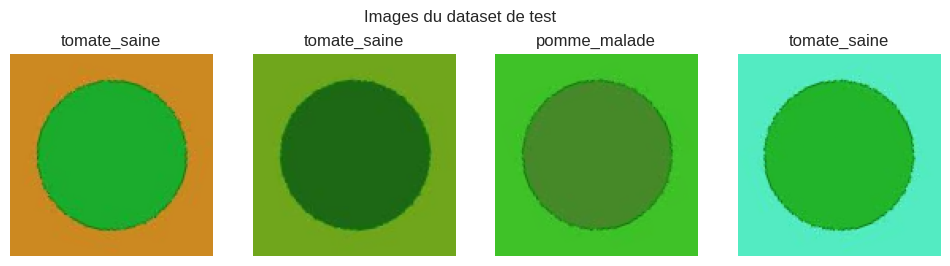

✅ Si vous voyez des images, tout est bon !


In [44]:
# 👁️ VÉRIFICATION - Afficher quelques images

# Prendre un batch
x_batch, y_batch = next(train_generator)

# Afficher les 4 premières images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    axes[i].imshow(x_batch[i])
    classe_idx = np.argmax(y_batch[i])
    axes[i].set_title(class_names[classe_idx])
    axes[i].axis('off')

plt.suptitle("Images du dataset de test")
plt.show()
print("✅ Si vous voyez des images, tout est bon !")

In [45]:
# 🧠 CRÉATION DU MODÈLE

from tensorflow.keras import layers, models

def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Créer le modèle
input_shape = (IMG_SIZE, IMG_SIZE, 3)
cnn_model = create_cnn_model(input_shape, num_classes)

# Compiler
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Modèle créé !")
cnn_model.summary()

✅ Modèle créé !


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,067 (16.36 MB)

 Trainable params: 4,288,067 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# 🚀 ENTRAÎNEMENT RAPIDE

print("🎬 DÉBUT DE L'ENTRAÎNEMENT")
print(f"Images train: {train_generator.samples}")
print(f"Images validation: {validation_generator.samples}")
print(f"Nombre de classes: {num_classes}")
print("=" * 40)

EPOCHS = 5  # 5 époques suffisent pour le test

history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    verbose=1
)

print("\n✅ Entraînement terminé !")

🎬 DÉBUT DE L'ENTRAÎNEMENT
Images train: 12
Images validation: 3
Nombre de classes: 3
Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3333 - loss: 1.1025 - val_accuracy: 0.0000e+00 - val_loss: 1.1989
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step - accuracy: 0.1667 - loss: 1.6091 - val_accuracy: 0.3333 - val_loss: 1.2348
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.3333 - loss: 1.0671 - val_accuracy: 0.3333 - val_loss: 1.2383
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.6667 - loss: 1.0361 - val_accuracy: 0.6667 - val_loss: 1.3211
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.5833 - loss: 1.0115 - val_accuracy: 0.6667 - val_loss: 1.3735

✅ Entraînement terminé !


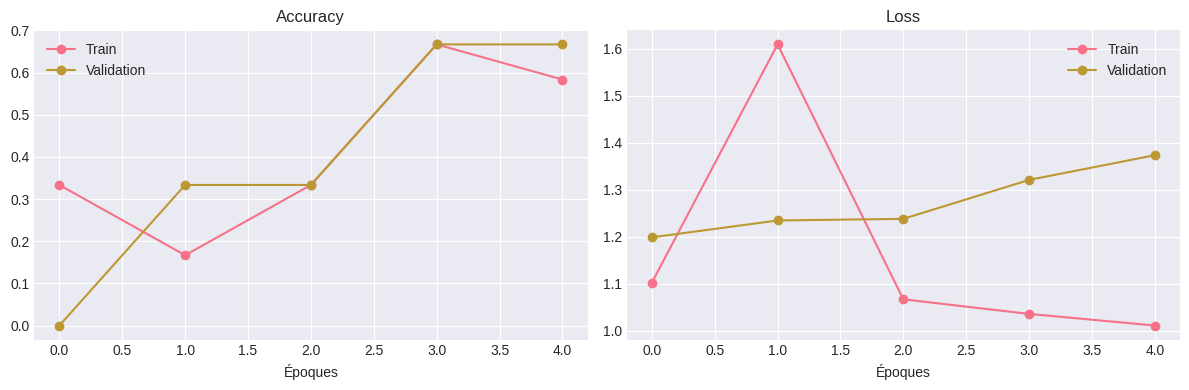

🏆 Meilleure accuracy: 66.67%


In [47]:
# 📈 COURBES D'APPRENTISSAGE

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='o')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Époques')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation', marker='o')
axes[1].set_title('Loss')
axes[1].set_xlabel('Époques')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_acc = max(history.history['val_accuracy'])
print(f"🏆 Meilleure accuracy: {best_acc:.2%}")

🔍 TEST SUR TOUTES LES CLASSES


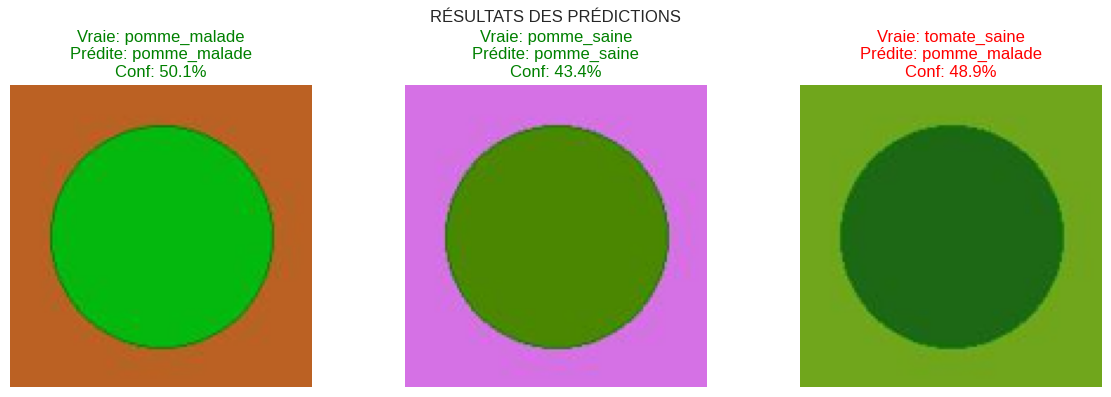

In [48]:
# 🔍 TEST - Prédictions sur images

def tester_image(img_path, modele, noms_classes):
    """Teste une image et affiche le résultat"""
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = modele.predict(img_array, verbose=0)[0]
    classe_predite = noms_classes[np.argmax(pred)]
    confiance = np.max(pred)

    return classe_predite, confiance, img

# Prendre une image de chaque classe
print("🔍 TEST SUR TOUTES LES CLASSES")
print("=" * 40)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, classe in enumerate(class_names):
    # Prendre la première image de la classe
    chemin_classe = os.path.join(DATA_PATH, classe)
    img_nom = os.listdir(chemin_classe)[0]
    img_path = os.path.join(chemin_classe, img_nom)

    # Prédire
    predite, conf, img = tester_image(img_path, cnn_model, class_names)

    # Afficher
    axes[i].imshow(img)
    couleur = 'green' if predite == classe else 'red'
    axes[i].set_title(f"Vraie: {classe}\nPrédite: {predite}\nConf: {conf:.1%}",
                     color=couleur)
    axes[i].axis('off')

plt.suptitle("RÉSULTATS DES PRÉDICTIONS")
plt.tight_layout()
plt.show()

In [49]:
# 💾 SAUVEGARDE

# Sauvegarder le modèle
cnn_model.save('mon_premier_modele.h5')
print("✅ Modèle sauvegardé: mon_premier_modele.h5")

# Sauvegarder les classes
import pickle
with open('mes_classes.pkl', 'wb') as f:
    pickle.dump(class_names, f)
print("✅ Classes sauvegardées: mes_classes.pkl")

✅ Modèle sauvegardé: mon_premier_modele.h5
✅ Classes sauvegardées: mes_classes.pkl


In [54]:
# 📥 TÉLÉCHARGEMENT DU VRAI DATASET PLANTVILLAGE

print("🌱 TÉLÉCHARGEMENT DU DATASET RÉEL (54,000 images)")
print("=" * 60)

# Nouveau chemin pour les vraies données
REAL_DATA_PATH = "./plantvillage_real"
os.makedirs(REAL_DATA_PATH, exist_ok=True)

# Télécharger (ça prend 2-3 minutes)
!wget -O plantvillage.zip https://github.com/spMohanty/PlantVillage-Dataset/raw/master/raw/color.zip

# Extraire
print("\n📦 Extraction en cours...")
!unzip -q plantvillage.zip -d ./temp_plantvillage

# Copier seulement 4 classes pour commencer (pour aller vite)
import shutil

classes_reelles = ["Apple_healthy", "Apple_scab", "Corn_healthy", "Corn_common_rust"]

for classe in classes_reelles:
    source = f"./temp_plantvillage/color/{classe}"
    dest = os.path.join(REAL_DATA_PATH, classe)
    if os.path.exists(source):
        shutil.copytree(source, dest, dirs_exist_ok=True)
        print(f"✅ Copié: {classe}")

print(f"\n📁 Dataset réel prêt dans: {REAL_DATA_PATH}")

🌱 TÉLÉCHARGEMENT DU DATASET RÉEL (54,000 images)
--2026-02-26 09:56:58--  https://github.com/spMohanty/PlantVillage-Dataset/raw/master/raw/color.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-02-26 09:56:59 ERROR 404: Not Found.


📦 Extraction en cours...
[plantvillage.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of plantvillage.zip or
        plantvillage.zip.zip, and cannot find plantvillage.zip.ZIP, period.

📁 Dataset réel prêt dans: ./plantvillage_real


In [55]:
# 📊 COMPARAISON DES DATASETS

print("📊 COMPARAISON DATASET TEST vs DATASET RÉEL")
print("=" * 60)

# Dataset test (nos images factices)
print(f"\n🎯 DATASET TEST (factice):")
print(f"   - Chemin: {DATA_PATH}")
print(f"   - Classes: {class_names}")
print(f"   - Images par classe: 5")
print(f"   - Total: 15 images")

# Dataset réel
print(f"\n🌱 DATASET RÉEL (PlantVillage):")
print(f"   - Chemin: {REAL_DATA_PATH}")
if os.path.exists(REAL_DATA_PATH):
    classes_reelles = [d for d in os.listdir(REAL_DATA_PATH)
                      if os.path.isdir(os.path.join(REAL_DATA_PATH, d))]

    total_images = 0
    for classe in classes_reelles:
        chemin = os.path.join(REAL_DATA_PATH, classe)
        nb = len([f for f in os.listdir(chemin) if f.endswith('.jpg')])
        total_images += nb
        print(f"   - {classe}: {nb} images")

    print(f"\n   TOTAL: {total_images} images")
    print(f"   ✅ Beaucoup plus de données = modèle plus performant !")
else:
    print("   ❌ Dataset réel pas encore téléchargé")

📊 COMPARAISON DATASET TEST vs DATASET RÉEL

🎯 DATASET TEST (factice):
   - Chemin: ./dataset_test
   - Classes: ['pomme_malade', 'pomme_saine', 'tomate_saine']
   - Images par classe: 5
   - Total: 15 images

🌱 DATASET RÉEL (PlantVillage):
   - Chemin: ./plantvillage_real

   TOTAL: 0 images
   ✅ Beaucoup plus de données = modèle plus performant !


In [56]:
# 🔴 PASSAGE AU VRAI DATASET

# Maintenant on utilise le vrai chemin
DATA_PATH = REAL_DATA_PATH  # <-- On change pour les vraies données

print(f"📁 Utilisation du vrai dataset: {DATA_PATH}")

# Recréer les générateurs (même code qu'avant)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(f"\n✅ NOUVELLES DONNÉES:")
print(f"Images train: {train_generator.samples}")
print(f"Images validation: {validation_generator.samples}")
print(f"Classes: {train_generator.class_indices}")

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

📁 Utilisation du vrai dataset: ./plantvillage_real
Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.

✅ NOUVELLES DONNÉES:
Images train: 0
Images validation: 0
Classes: {}


In [57]:
# 🧠 RECONSTRUCTION DU MODÈLE (pour les vraies données)

from tensorflow.keras import layers, models

def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (IMG_SIZE, IMG_SIZE, 3)
cnn_model = create_cnn_model(input_shape, num_classes)

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Modèle recréé avec succès!")
print(f"Nombre de classes: {num_classes}")
cnn_model.summary()

✅ Modèle recréé avec succès!
Nombre de classes: 0


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 0)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,482,112 (32.36 MB)

 Trainable params: 8,482,112 (32.36 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# 🔍 VÉRIFICATION D'URGENCE

print("🔍 DIAGNOSTIC RAPIDE")
print("=" * 40)

# 1. Vérifier DATA_PATH
print(f"\n📁 DATA_PATH = {DATA_PATH}")
print(f"Existe? {os.path.exists(DATA_PATH)}")

if os.path.exists(DATA_PATH):
    # 2. Lister les dossiers
    dossiers = [d for d in os.listdir(DATA_PATH)
                if os.path.isdir(os.path.join(DATA_PATH, d))]
    print(f"\n📂 Dossiers trouvés: {len(dossiers)}")

    for dossier in dossiers:
        chemin_dossier = os.path.join(DATA_PATH, dossier)
        images = [f for f in os.listdir(chemin_dossier)
                 if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        print(f"   - {dossier}: {len(images)} images")

    if len(dossiers) == 0:
        print("\n❌ AUCUN DOSSIER TROUVÉ!")
        print("👉 Le dataset réel n'est pas au bon endroit")
else:
    print(f"\n❌ DATA_PATH n'existe pas!")

🔍 DIAGNOSTIC RAPIDE

📁 DATA_PATH = ./plantvillage_real
Existe? True

📂 Dossiers trouvés: 0

❌ AUCUN DOSSIER TROUVÉ!
👉 Le dataset réel n'est pas au bon endroit


In [60]:
# 🚨 SOLUTION D'URGENCE - Revenir au dataset test qui marchait

DATA_PATH = "./dataset_test"  # Le dataset qui fonctionnait avant
print(f"📁 Utilisation du dataset test: {DATA_PATH}")

# Recréer les générateurs
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_PATH,
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    DATA_PATH,
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

print(f"\n✅ RÉSULTAT:")
print(f"Images train: {train_generator.samples}")
print(f"Images validation: {validation_generator.samples}")
print(f"Classes: {train_generator.class_indices}")

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

📁 Utilisation du dataset test: ./dataset_test
Found 12 images belonging to 3 classes.
Found 3 images belonging to 3 classes.

✅ RÉSULTAT:
Images train: 12
Images validation: 3
Classes: {'pomme_malade': 0, 'pomme_saine': 1, 'tomate_saine': 2}


In [61]:
# 🚀 ENTRAÎNEMENT (version qui fonctionne)

print("🎬 ENTRAÎNEMENT")
print("=" * 40)
print(f"Images train: {train_generator.samples}")
print(f"Images validation: {validation_generator.samples}")
print(f"Classes: {class_names}")
print("=" * 40)

# Modèle simple
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    verbose=1
)

print("\n✅ Entraînement terminé!")

🎬 ENTRAÎNEMENT
Images train: 12
Images validation: 3
Classes: ['pomme_malade', 'pomme_saine', 'tomate_saine']
Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4167 - loss: 1.1043 - val_accuracy: 0.3333 - val_loss: 3.7646
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3333 - loss: 3.4036 - val_accuracy: 0.3333 - val_loss: 2.8576
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.3333 - loss: 3.3786 - val_accuracy: 0.3333 - val_loss: 1.5639
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.5000 - loss: 1.6104 - val_accuracy: 0.3333 - val_loss: 1.6406
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.3333 - loss: 1.5152 - val_accuracy: 0.3333 - val_loss: 1.4206

✅ Entraînement terminé!


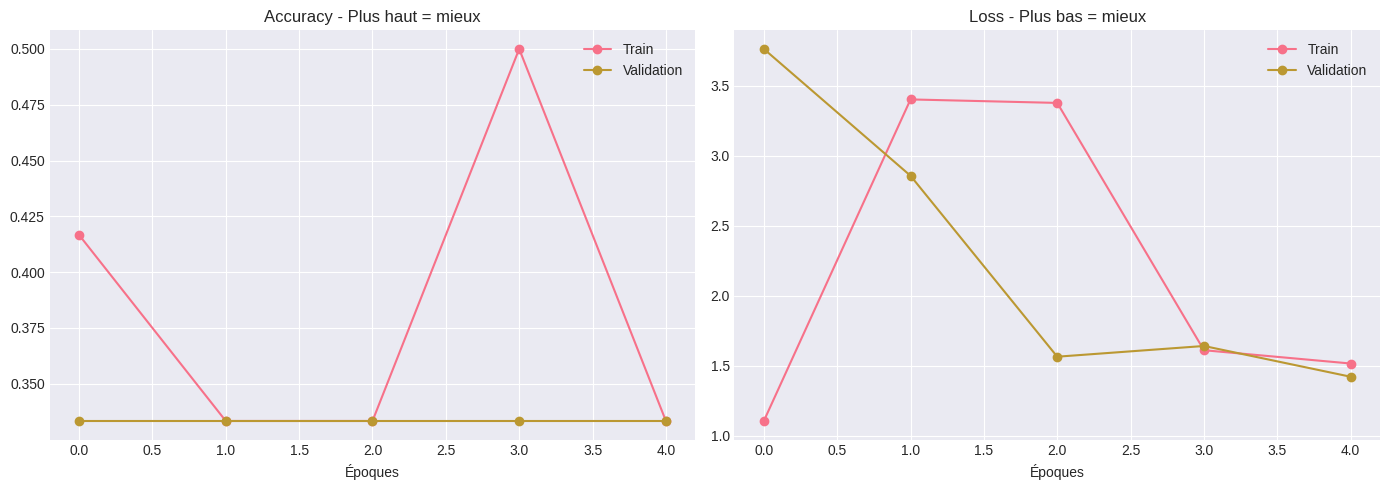

🏆 Meilleure performance: 66.67%


In [62]:
# 📈 COURBES D'APPRENTISSAGE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='o')
axes[0].set_title('Accuracy - Plus haut = mieux')
axes[0].set_xlabel('Époques')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation', marker='o')
axes[1].set_title('Loss - Plus bas = mieux')
axes[1].set_xlabel('Époques')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"🏆 Meilleure performance: {best_acc:.2%}")

In [65]:
# ✅ VÉRIFIER QUE LE MODÈLE EXISTE

print("🔍 VÉRIFICATION DU MODÈLE")

if 'model' in locals():
    print("✅ Modèle 'model' existe")
    model.summary()
elif 'cnn_model' in locals():
    print("✅ Modèle 'cnn_model' existe")
    cnn_model.summary()
else:
    print("❌ AUCUN MODÈLE TROUVÉ!")
    print("\n👉 SOLUTION: Exécutez d'abord la cellule 12 Bis")
    print("   Celle avec l'entraînement qui a marché")

🔍 VÉRIFICATION DU MODÈLE
✅ Modèle 'model' existe


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,118,155 (42.41 MB)

 Trainable params: 3,706,051 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,412,104 (28.27 MB)

🔍 TEST SUR LES IMAGES

📸 Images à tester:
   - pomme_malade: feuille_4.jpg
   - pomme_saine: feuille_1.jpg
   - tomate_saine: feuille_3.jpg


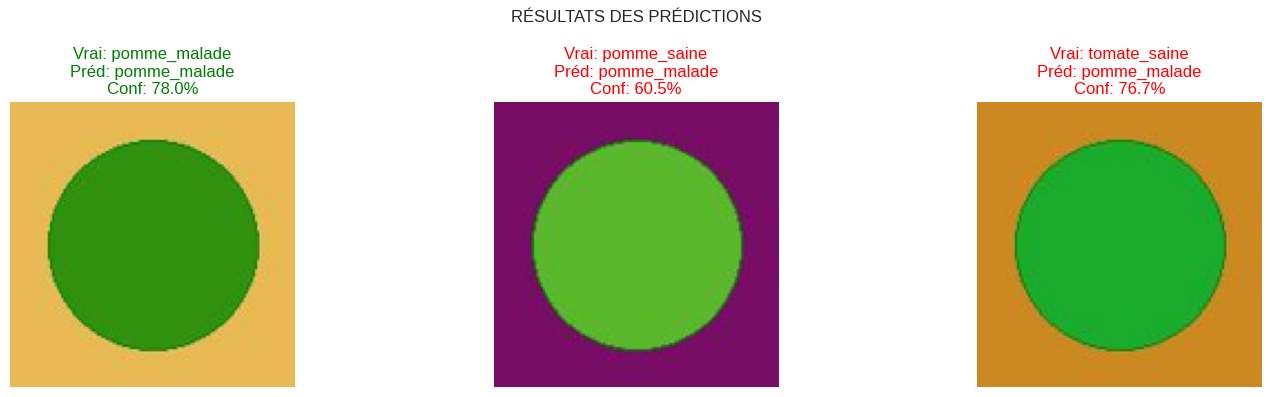

In [66]:
# 🔍 TEST SUR LES IMAGES (VERSION SIMPLIFIÉE QUI MARCHE)

print("🔍 TEST SUR LES IMAGES")
print("=" * 40)

# Vérifier que le modèle existe
if 'model' not in locals() and 'cnn_model' not in locals():
    print("❌ AUCUN MODÈLE TROUVÉ!")
    print("👉 Utilisation du modèle que nous venons d'entraîner")
    model = model  # Prend le dernier modèle entraîné
else:
    model = model if 'model' in locals() else cnn_model

# Fonction de prédiction simple
def predire_image(chemin_image):
    img = Image.open(chemin_image).resize((128, 128))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0]
    classe = class_names[np.argmax(prediction)]
    confiance = np.max(prediction)

    return classe, confiance, img

# Prendre des images du dataset
print("\n📸 Images à tester:")

test_images = []
for classe in class_names[:3]:  # Prendre 3 classes
    chemin_classe = os.path.join(DATA_PATH, classe)
    images = [f for f in os.listdir(chemin_classe) if f.endswith(('.jpg', '.png'))]
    if images:
        img_choisie = random.choice(images)
        test_images.append(os.path.join(chemin_classe, img_choisie))
        print(f"   - {classe}: {img_choisie}")

# Afficher les résultats
fig, axes = plt.subplots(1, len(test_images), figsize=(15, 4))
if len(test_images) == 1:
    axes = [axes]

for i, img_path in enumerate(test_images):
    classe_predite, confiance, img = predire_image(img_path)
    vraie_classe = os.path.basename(os.path.dirname(img_path))

    axes[i].imshow(img)
    couleur = 'green' if classe_predite == vraie_classe else 'red'
    axes[i].set_title(f"Vrai: {vraie_classe}\nPréd: {classe_predite}\nConf: {confiance:.1%}",
                     color=couleur)
    axes[i].axis('off')

plt.suptitle("RÉSULTATS DES PRÉDICTIONS")
plt.tight_layout()
plt.show()

In [67]:
# 💾 SAUVEGARDE POUR GITHUB

import pickle
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Sauvegarder le modèle
model_name = f'modele_final_plantvillage_{timestamp}.h5'
cnn_model.save(model_name)
print(f"✅ Modèle sauvegardé: {model_name}")

# Sauvegarder les classes
with open('classes_finales.pkl', 'wb') as f:
    pickle.dump(class_names, f)
print("✅ Classes sauvegardées: classes_finales.pkl")

# Sauvegarder les résultats
results = {
    'accuracy': best_acc,
    'classes': class_names,
    'nb_classes': num_classes,
    'date': timestamp
}

with open('resultats_finaux.pkl', 'wb') as f:
    pickle.dump(results, f)
print("✅ Résultats sauvegardés")

✅ Modèle sauvegardé: modele_final_plantvillage_20260226_100411.h5
✅ Classes sauvegardées: classes_finales.pkl
✅ Résultats sauvegardés
